In [1]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pickle

In [2]:
with open('../data/pca_data.pkl', 'rb') as f:
      data = pickle.load(f)

In [3]:
df = data['df']
X = data['X']
X_scaled = data['X_scaled']
X_pca = data['X_pca']
pca = data['pca']
feature_cols = data['feature_cols']

X.shape, X_scaled.shape, X_pca.shape

((98, 40), (98, 40), (98, 9))

In [4]:
df.head()

player_id,player_name,player_fullname,RATING_3_0,T_RATING,CT_RATING,ROUND_SWING,DPR,KAST,MULTI_KILL,ADR,KPR,Total_kills,Headshot_pct,Total_deaths,KD_Ratio,Damage_per_Round,Grenade_dmg_per_Round,Maps_played,Rounds_played,Kills_per_round,Assists_per_round,Deaths_per_round,Saved_by_teammate_per_round,Saved_teammates_per_round,Impact_rating,total_kills_weapon,rifle_kills,rifle_pct,sniper_kills,sniper_pct,pistol_kills,pistol_pct,smg_kills,smg_pct,ak47_kills,m4a1_kills,m4a1s_kills,awp_kills,ssg08_kills,deagle_kills,glock_kills,usp_kills,sniper_kills_log,sniper_pct_log,awp_kills_log,ssg08_kills_log
i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,f64,i64,f64,i64,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64
21167,"""donk""","""Danil Kryshkovets""",1.41,1.46,1.38,3.72,0.66,77.8,25.1,94.5,0.9,889,61.4,652,1.36,94.5,3.6,47,985,0.9,0.23,0.66,0.13,0.15,1.64,889,722,81.2,11,1.2,142,16.0,7,0.8,514,109,68,11,0,38,33,40,2.484907,0.788457,2.484907,0.0
11893,"""ZywOo""","""Mathieu Herbaut""",1.36,1.38,1.35,4.03,0.55,77.6,22.3,85.1,0.86,1053,41.0,672,1.57,85.1,4.2,56,1228,0.86,0.17,0.55,0.1,0.12,1.44,1053,395,37.5,441,41.9,180,17.1,17,1.6,277,81,5,429,12,35,40,25,6.09131,3.758872,6.063785,2.564949
19230,"""m0NESY""","""Ilya Osipov""",1.28,1.17,1.39,3.78,0.59,76.7,20.4,81.0,0.81,823,36.3,599,1.37,81.0,3.3,45,1016,0.81,0.13,0.59,0.1,0.1,1.26,888,236,26.6,492,55.4,135,15.2,9,1.0,141,28,41,473,19,14,41,17,6.200509,4.032469,6.161207,2.995732
21667,"""Magnojez""","""Kirill Rodnov""",1.21,1.17,1.24,1.78,0.68,74.2,19.5,86.0,0.77,1202,52.2,1068,1.13,86.0,3.3,75,1568,0.77,0.24,0.68,0.09,0.1,1.36,1202,876,72.9,26,2.2,182,15.1,98,8.2,491,67,253,23,3,13,40,55,3.295837,1.163151,3.178054,1.386294
16693,"""flameZ""","""Shahar Shushan""",1.2,1.17,1.24,1.45,0.66,76.6,20.0,78.8,0.75,924,53.2,806,1.15,78.8,3.6,56,1228,0.75,0.19,0.66,0.14,0.11,1.27,924,624,67.5,2,0.2,125,13.5,165,17.9,310,273,4,2,0,16,43,35,1.098612,0.182322,1.098612,0.0


In [5]:
# Tried clusters from 2 to 11
ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=20).fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, km.labels_))

cluster_scores = pd.DataFrame({
    'k': list(ks),
    'inertia': inertias,
    'silhouette': silhouettes
})

cluster_scores

,k,inertia,silhouette
0,2,2695.433163,0.313272
1,3,2015.762437,0.258321
2,4,1788.789024,0.191408
3,5,1622.430325,0.217519
4,6,1506.560464,0.213518
5,7,1374.385133,0.200054
6,8,1305.636265,0.174010
7,9,1246.110678,0.175100
8,10,1189.758958,0.167905


Overall, we can see that at k=2, the silhouette is the largest at 0.31. 

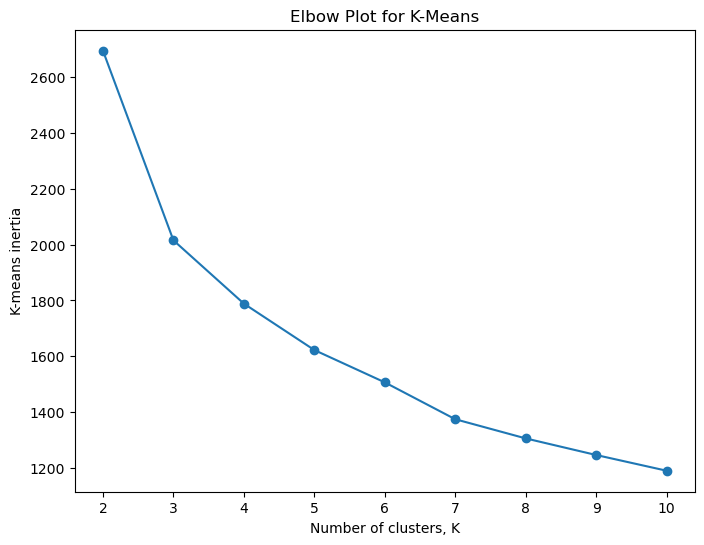

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(cluster_scores['k'],
        cluster_scores['inertia'],
        marker='o')

ax.set_xlabel('Number of clusters, K')
ax.set_ylabel('K-means inertia')
ax.set_title('Elbow Plot for K-Means')

# Save figure
fig.savefig('kmeans_elbow_silhouette.jpg',
            dpi=300,
            bbox_inches='tight')

plt.show()

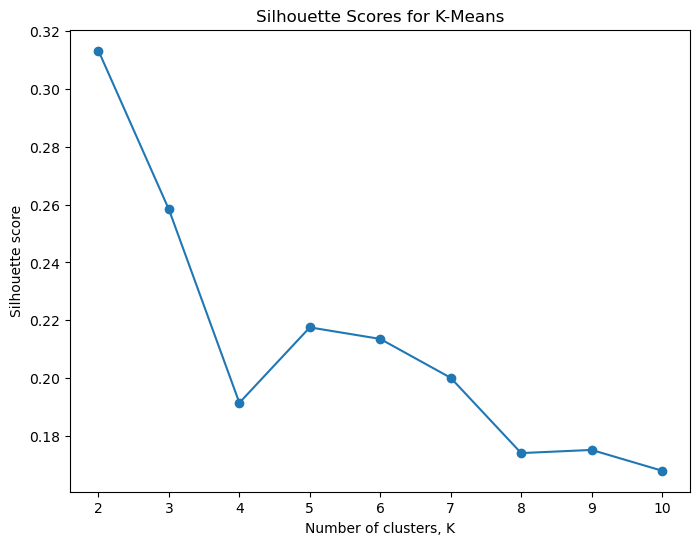

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(cluster_scores['k'],
        cluster_scores['silhouette'],
        marker='o')

ax.set_xlabel('Number of clusters, K')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette Scores for K-Means')

# Save figure
fig.savefig('kmeans_silhouette_scores.jpg',
            dpi=300,
            bbox_inches='tight')

plt.show()

## Fit the final K-means model

We tried both k=2 and k=3. k=2 has a higher silhouette score, so the final cluster will be k=2

### Plot k=2

In [8]:
kmeans = KMeans(n_clusters=2,
                random_state=0,
                n_init=20).fit(X_pca)

kmeans.labels_

array([1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

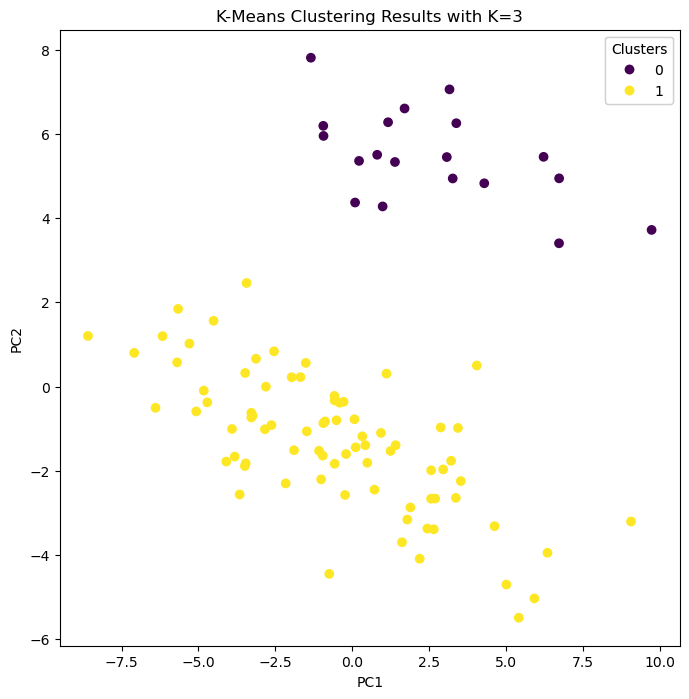

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans.labels_
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means Clustering Results with K=3')

# Create legend
legend = ax.legend(
    *scatter.legend_elements(),
    title='Clusters'
)

ax.add_artist(legend)

fig.savefig('kmeans_pca_clusters.jpg',
            dpi=300,
            bbox_inches='tight')

### Plot k=3

In [10]:
kmeans3 = KMeans(n_clusters=3,
                random_state=0,
                n_init=20).fit(X_pca)

kmeans3.labels_

array([2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 1, 1, 2, 2, 2, 2, 0, 2, 1, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1,
       0, 2, 1, 1, 0, 1, 1, 0, 1, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

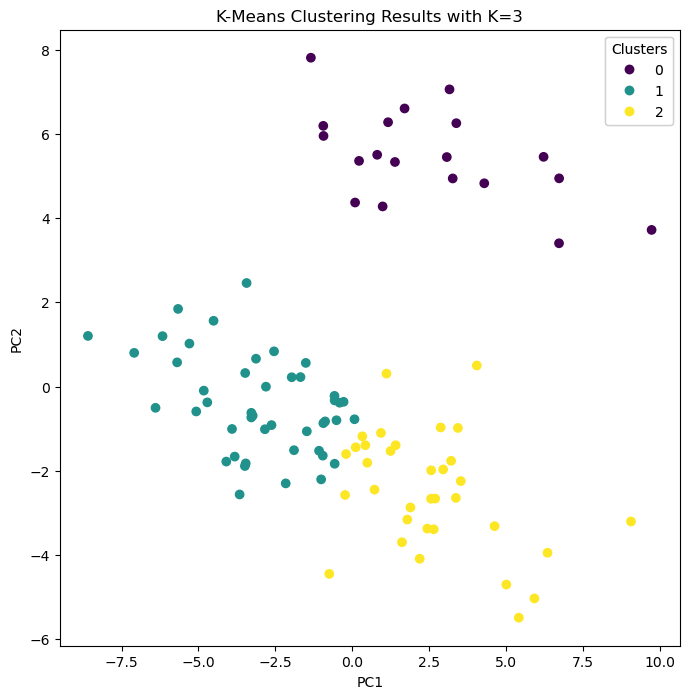

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans3.labels_
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means Clustering Results with K=3')

# Create legend
legend = ax.legend(
    *scatter.legend_elements(),
    title='Clusters'
)

ax.add_artist(legend)

fig.savefig('kmeans_pca_clusters.jpg',
            dpi=300,
            bbox_inches='tight')

Since k=2 is better, but we want to use k=3 for our final cluster results.

In [12]:
cluster_results = X.copy().reset_index()
cluster_results['cluster'] = kmeans3.labels_

if hasattr(df, 'select'):
    name_cols = [col for col in ['player_id', 'player_name', 'player_fullname'] if col in df.columns]
    if name_cols:
        names_pd = pd.DataFrame(df.select(name_cols).to_dicts())
        cluster_results = names_pd.merge(cluster_results, on='player_id', how='right')
else:
    name_cols = [col for col in ['player_id', 'player_name', 'player_fullname'] if col in df.columns]
    if name_cols:
        cluster_results = df[name_cols].merge(cluster_results, on='player_id', how='right')

cluster_results.head(10)

,player_id,player_name,player_fullname,RATING_3_0,T_RATING,CT_RATING,ROUND_SWING,DPR,KAST,MULTI_KILL,...,m4a1_kills,m4a1s_kills,deagle_kills,glock_kills,usp_kills,sniper_kills_log,sniper_pct_log,awp_kills_log,ssg08_kills_log,cluster
0,21167,donk,Danil Kryshkovets,1.41,1.46,1.38,3.72,0.66,77.8,25.1,...,109,68,38,33,40,2.484907,0.788457,2.484907,0.000000,2
1,11893,ZywOo,Mathieu Herbaut,1.36,1.38,1.35,4.03,0.55,77.6,22.3,...,81,5,35,40,25,6.091310,3.758872,6.063785,2.564949,0
2,19230,m0NESY,Ilya Osipov,1.28,1.17,1.39,3.78,0.59,76.7,20.4,...,28,41,14,41,17,6.200509,4.032469,6.161207,2.995732,0
3,21667,Magnojez,Kirill Rodnov,1.21,1.17,1.24,1.78,0.68,74.2,19.5,...,67,253,13,40,55,3.295837,1.163151,3.178054,1.386294,2
4,16693,flameZ,Shahar Shushan,1.20,1.17,1.24,1.45,0.66,76.6,20.0,...,273,4,16,43,35,1.098612,0.182322,1.098612,0.000000,2
5,11816,ropz,Robin Kool,1.19,1.19,1.19,1.75,0.57,76.9,19.1,...,260,16,26,47,30,3.295837,1.360977,3.295837,0.000000,2
6,22673,makazze,Drin Shaqiri,1.20,1.18,1.22,1.75,0.69,75.5,18.8,...,13,307,42,57,80,1.945910,0.405465,1.609438,1.098612,2
7,15631,KSCERATO,Kaike Cerato,1.18,1.14,1.22,1.30,0.63,74.6,18.5,...,110,197,21,32,39,2.639057,0.875469,2.639057,0.000000,2
8,20127,w0nderful,Ihor Zhdanov,1.17,1.20,1.15,1.68,0.57,76.4,19.6,...,66,32,67,27,38,6.363028,3.873282,6.318968,3.258097,0
9,20304,Staehr,Victor Staehr,1.17,1.15,1.19,1.65,0.67,72.7,18.4,...,166,118,43,50,60,1.386294,0.262364,1.098612,0.693147,2


In [13]:
cluster_results['cluster'].value_counts().sort_index()

cluster
0    19
1    45
2    34
Name: count, dtype: int64

In [14]:
cluster_summary = X.copy()
cluster_summary['cluster'] = kmeans3.labels_

cluster_summary.groupby('cluster').mean().T

cluster,0,1,2
RATING_3_0,1.090000,0.996444,1.142353
T_RATING,1.067368,0.978444,1.117941
CT_RATING,1.112105,1.013556,1.166471
ROUND_SWING,1.231579,-0.393111,1.085294
DPR,0.586316,0.656000,0.654706
KAST,73.836842,71.817778,73.844118
MULTI_KILL,17.257895,14.484444,18.205882
ADR,71.447368,69.244444,79.505882
KPR,0.705789,0.621333,0.730000
Total_kills,970.947368,782.577778,1021.264706


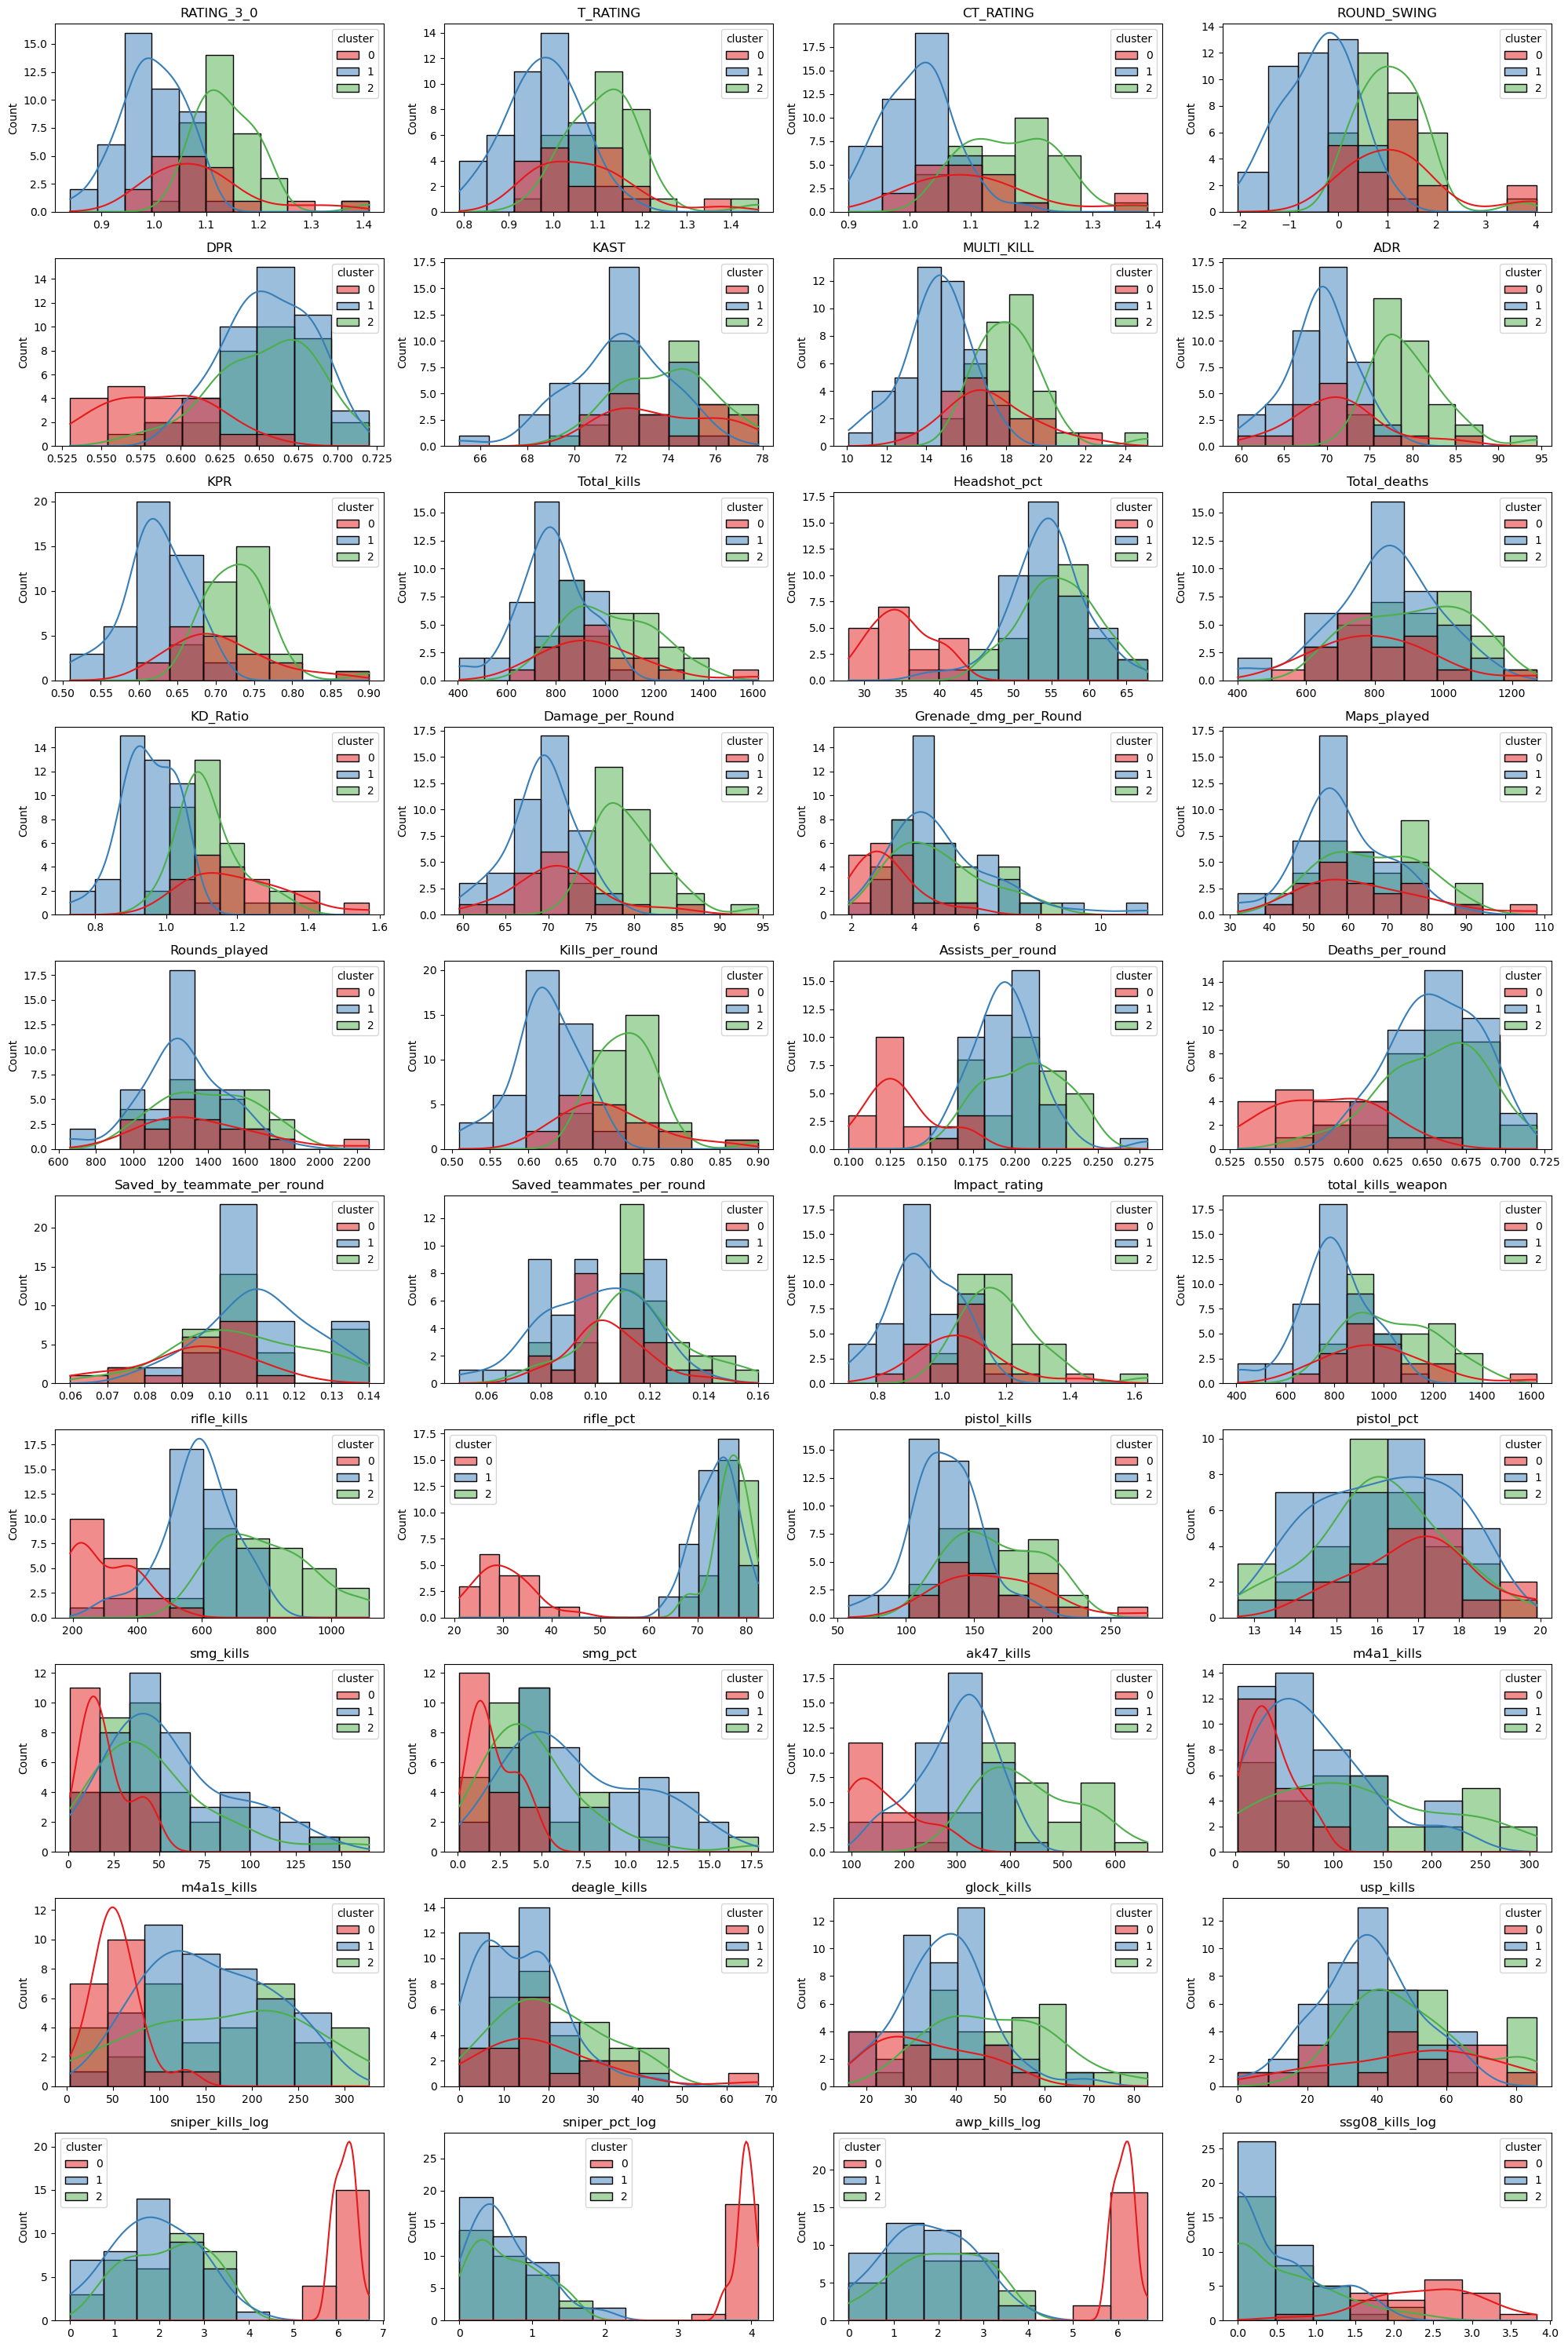

In [15]:
feature_cols = list(data['feature_cols'])

X_labeled = pd.DataFrame({'player_id': df['player_id'].to_list(), 'cluster': kmeans3.labels_})

df_labeled = df.join(
    pl.DataFrame(X_labeled),
    on='player_id',
    how='left'
)

agg_exprs = []
for col in feature_cols:
    agg_exprs += [
        pl.col(col).mean().alias(f'{col}_mean'),
        pl.col(col).std().alias(f'{col}_std'),
        pl.col(col).min().alias(f'{col}_min'),
        pl.col(col).max().alias(f'{col}_max'),
        pl.col(col).median().alias(f'{col}_median'),
    ]

cluster_agg = df_labeled.group_by('cluster').agg(agg_exprs).sort('cluster')
cluster_agg



df_plot = df_labeled.select(feature_cols + ['cluster']).to_pandas()

n_cols = 4
n_rows = -(-len(feature_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=df_plot, x=col, hue='cluster', kde=True, ax=axes[i], palette='Set1')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

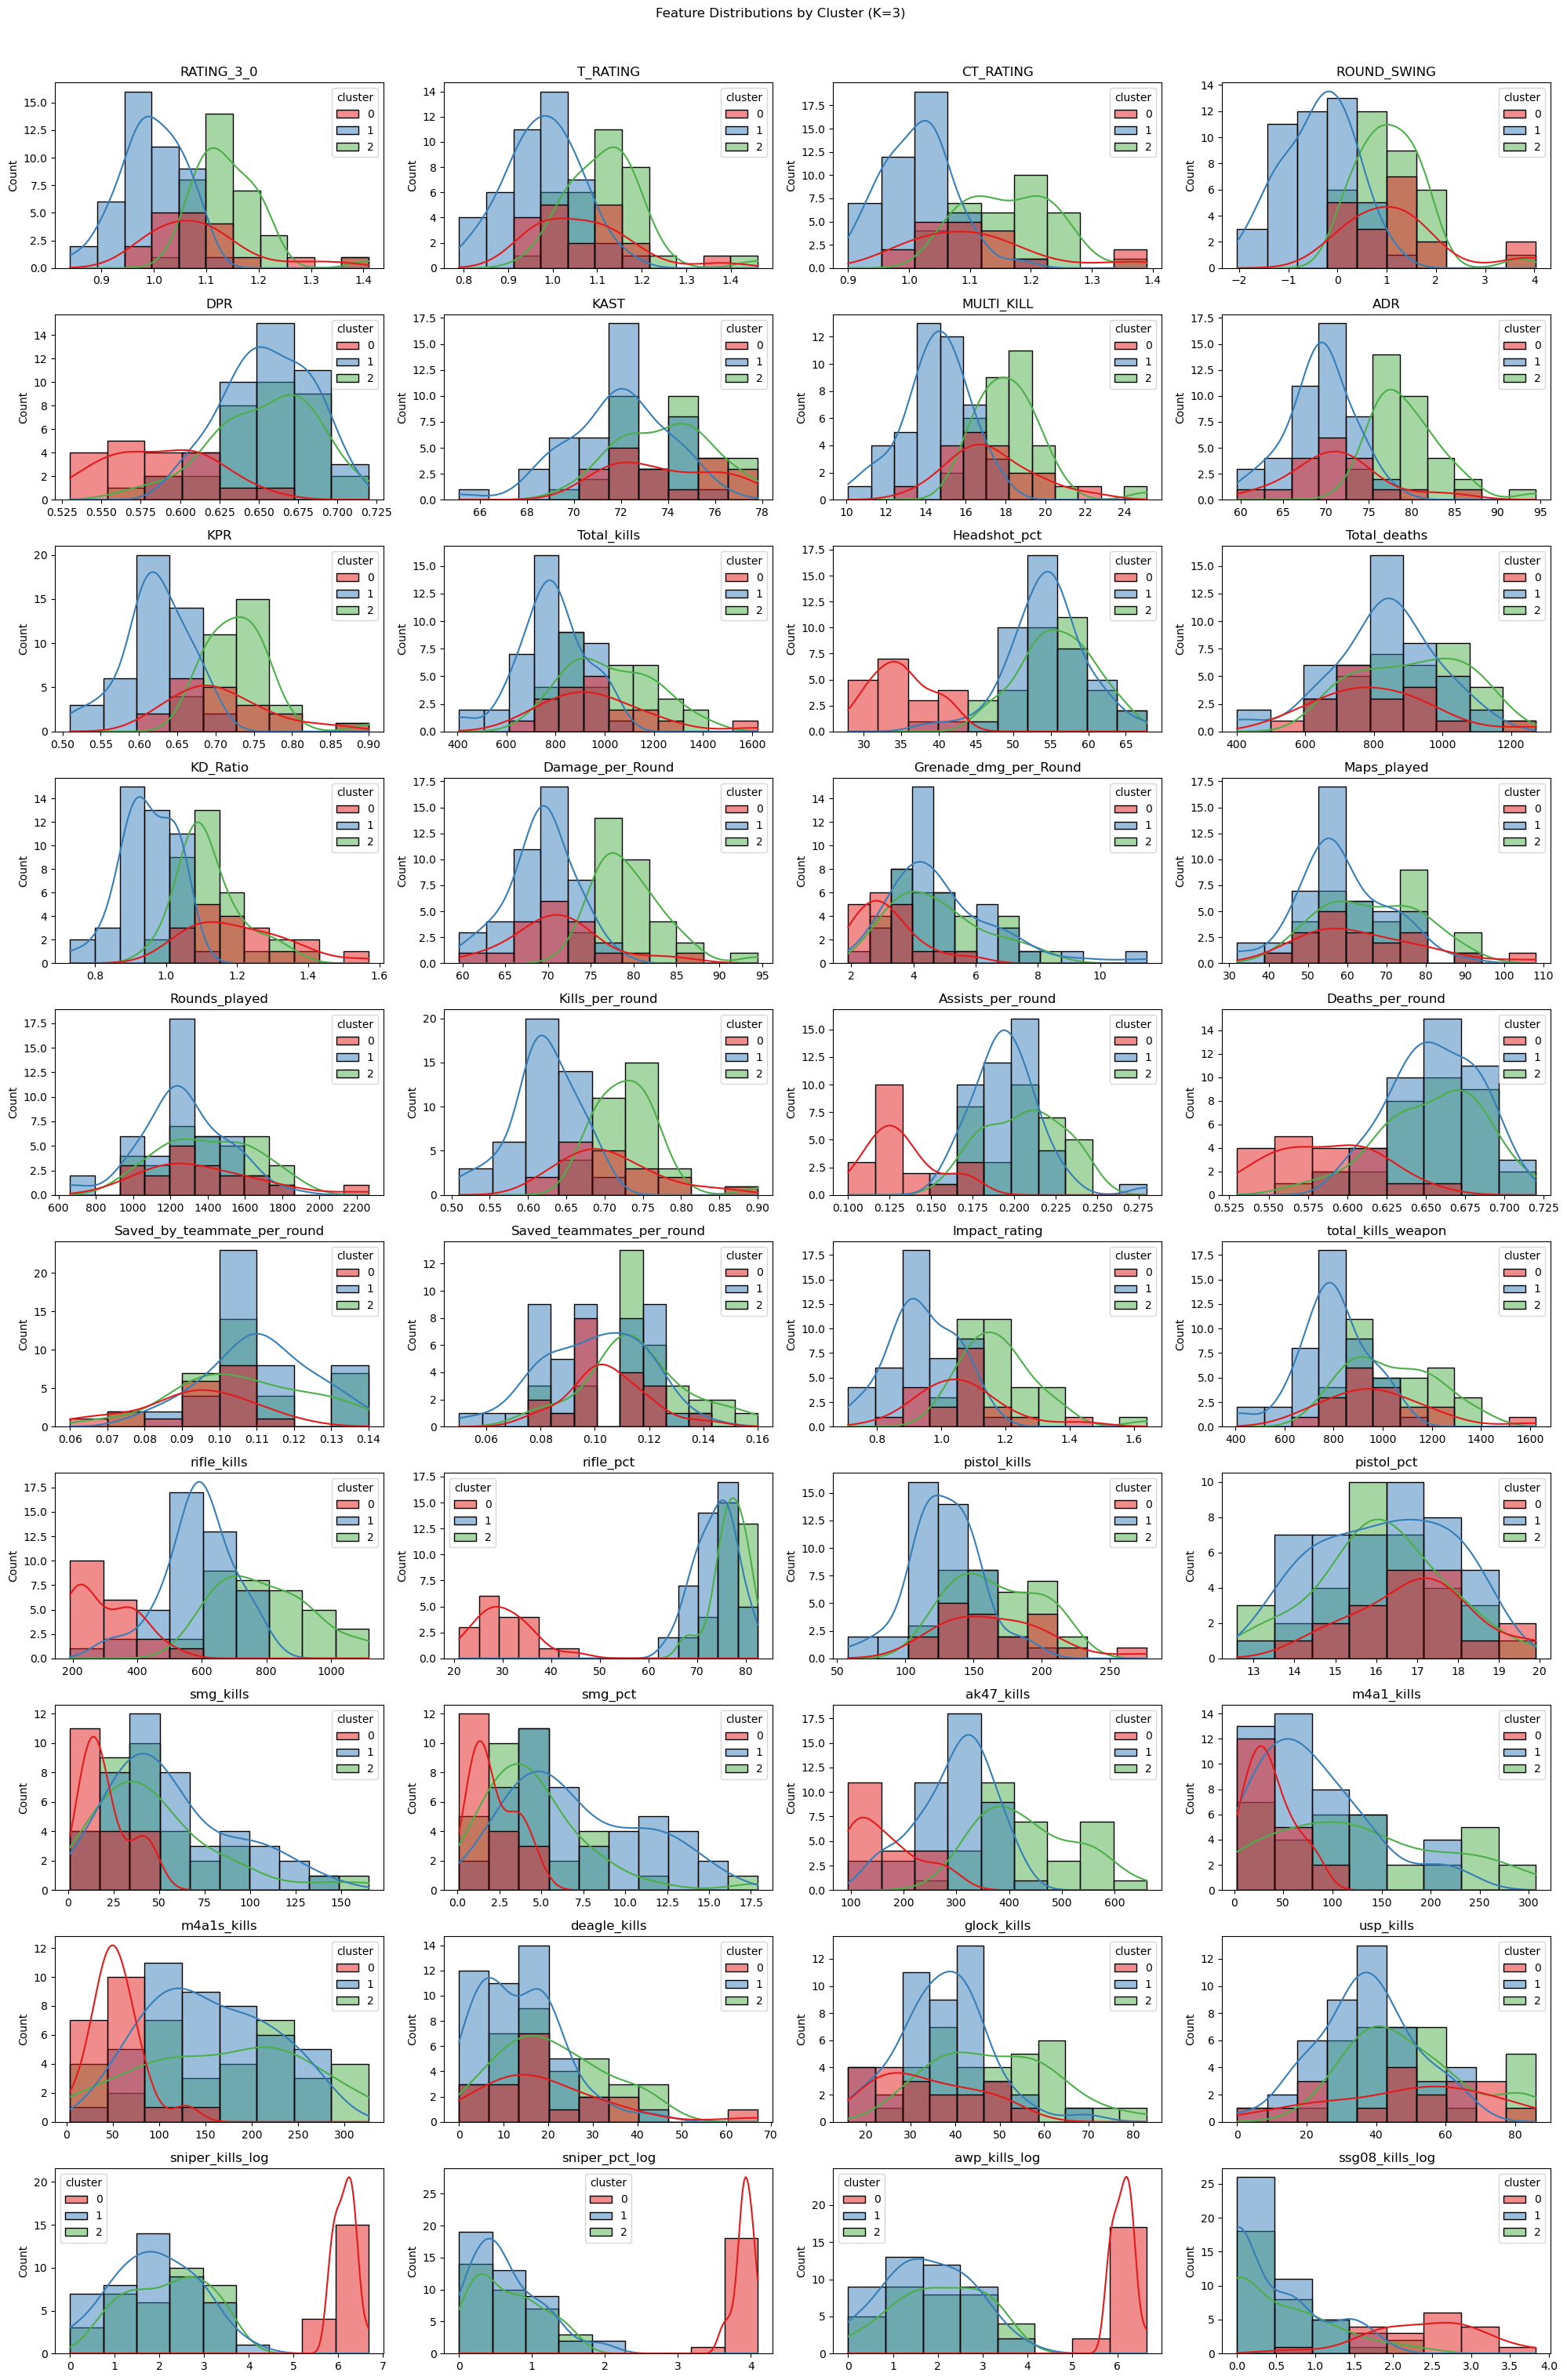

In [16]:
X_labeled3 = pd.DataFrame({'player_id': df['player_id'].to_list(), 'cluster': kmeans3.labels_})

df_labeled3 = df.join(
    pl.DataFrame(X_labeled3),
    on='player_id',
    how='left'
)

df_plot3 = df_labeled3.select(feature_cols + ['cluster']).to_pandas()

n_cols = 4
n_rows = -(-len(feature_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=df_plot3, x=col, hue='cluster', kde=True, ax=axes[i], palette='Set1')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Cluster (K=3)', y=1.01)
plt.tight_layout()
plt.show()

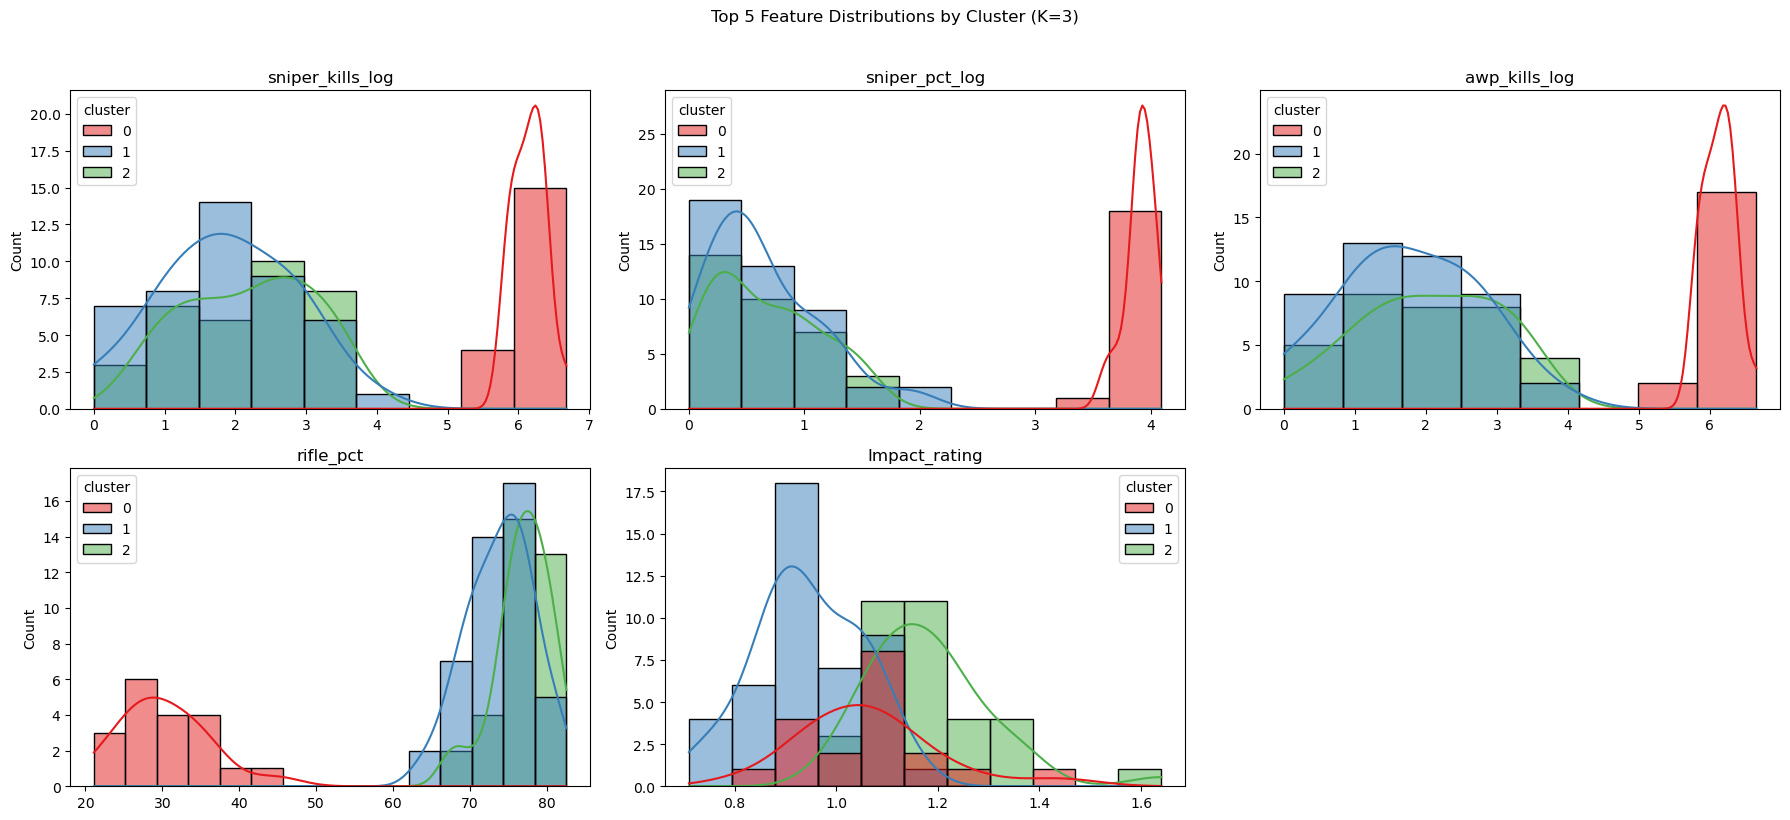

In [23]:
# Top 5 Features to Determine a Cluster

top5_features = [
    'sniper_kills_log',
    'sniper_pct_log',
    'awp_kills_log',
    'rifle_pct',
    'Impact_rating'
]

X_labeled3 = pd.DataFrame({
    'player_id': df['player_id'].to_list(),
    'cluster': kmeans3.labels_
})

df_labeled3 = df.join(
    pl.DataFrame(X_labeled3),
    on='player_id',
    how='left'
)

df_plot3 = df_labeled3.select(top5_features + ['cluster']).to_pandas()

n_cols = 3
n_rows = -(-len(top5_features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(top5_features):
    sns.histplot(
        data=df_plot3,
        x=col,
        hue='cluster',
        kde=True,
        ax=axes[i],
        palette='Set1'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 5 Feature Distributions by Cluster (K=3)', y=1.02)
plt.tight_layout()

fig.savefig('kmeans_top5_feature_distributions.jpg',
            dpi=300,
            bbox_inches='tight')

plt.show()